# Exploratory Data Analysis — ACNE04 & Patches

This notebook explores the ACNE04 dataset and the patch extraction output before model training.

## Contents
1. Setup
2. Dataset Statistics
3. Class Distribution & Bounding Box Analysis
4. Sample Images with Bounding Boxes
5. Patch Quality Check

## Key Findings
- ACNE04 contains 3,398 images across train/val/test splits
- 4 acne classes with significant imbalance: nodules and cysts (17,033) dominate, whiteheads (2,007) are underrepresented
- Bounding boxes per image: mean 13.4, median 7, max 65 — right-skewed distribution indicating mostly mild-moderate cases with severe outliers
- Patch extraction produced 39,713 train acne patches and 8,919 clear patches (~4.45:1 ratio) — class imbalance addressed via weighted loss during classifier training

## 1. Setup

In [5]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

# Navigate to repo root regardless of where notebook is
notebook_dir = Path().resolve()
repo_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
os.chdir(repo_root)
print(f'Working directory: {os.getcwd()}')

Working directory: /Users/krangwala/Desktop/Research/Yang lab/yanglab-acne


## 2. Dataset Statistics

In [6]:
ACNE04 = Path('data/acne04')
splits = ['train', 'valid', 'test']

for split in splits:
    images = list((ACNE04 / split / 'images').glob('*.jpg'))
    labels = list((ACNE04 / split / 'labels').glob('*.txt'))
    print(f'{split}: {len(images)} images, {len(labels)} label files')

train: 2973 images, 2973 label files
valid: 283 images, 283 label files
test: 142 images, 142 label files


### Observations
- Dataset is heavily skewed toward the training split (2,973 train vs 283 val vs 142 test)
- The test set is particularly small at 142 images — evaluation metrics should be interpreted with this in mind
- Every image has a matching label file, indicating a clean dataset with no missing annotations

## 3. Class Distribution & Bounding Box Analysis

In [7]:
CLASS_NAMES = ['nodules and cysts', 'papules', 'pustules', 'whitehead and blackhead']
class_counts = Counter()
boxes_per_image = []

for label_file in (ACNE04 / 'train' / 'labels').glob('*.txt'):
    with open(label_file) as f:
        lines = f.readlines()
    boxes_per_image.append(len(lines))
    for line in lines:
        class_id = int(line.strip().split()[0])
        class_counts[CLASS_NAMES[class_id]] += 1

print('Class distribution:')
for name, count in class_counts.most_common():
    print(f'  {name}: {count}')

print(f'\nBounding boxes per image:')
print(f'  min: {min(boxes_per_image)}')
print(f'  max: {max(boxes_per_image)}')
print(f'  mean: {np.mean(boxes_per_image):.1f}')
print(f'  median: {np.median(boxes_per_image):.1f}')

Class distribution:
  nodules and cysts: 17033
  pustules: 11091
  papules: 9583
  whitehead and blackhead: 2007

Bounding boxes per image:
  min: 0
  max: 65
  mean: 13.4
  median: 7.0


In [8]:
import os
print(os.getcwd())

/Users/krangwala/Desktop/Research/Yang lab/yanglab-acne


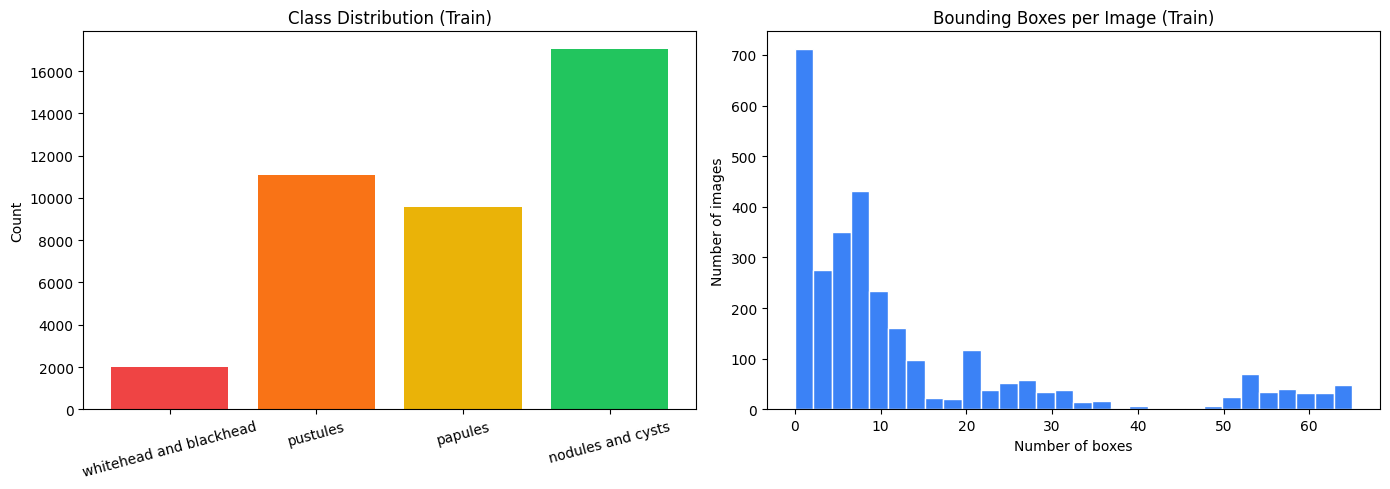

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(class_counts.keys(), class_counts.values(), color=['#ef4444', '#f97316', '#eab308', '#22c55e'])
axes[0].set_title('Class Distribution (Train)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

axes[1].hist(boxes_per_image, bins=30, color='#3b82f6', edgecolor='white')
axes[1].set_title('Bounding Boxes per Image (Train)')
axes[1].set_xlabel('Number of boxes')
axes[1].set_ylabel('Number of images')

plt.tight_layout()
plt.savefig('outputs/predictions/eda_distributions.png', dpi=150)
plt.show()

### Observations
- Nodules and cysts are the dominant class at 17,033 instances — nearly 8.5x more common than whiteheads and blackheads (2,007)
- This class imbalance will likely cause the model to underperform on whitehead detection — worth monitoring per-class AP during evaluation
- The bounding box distribution is right-skewed (mean 13.4, median 7) — most patients have mild-moderate acne severity with a long tail of severe cases up to 65 lesions per image
- Images with 0 bounding boxes contribute nothing to training and represent labeling edge cases

## 4. Sample Images with Bounding Boxes

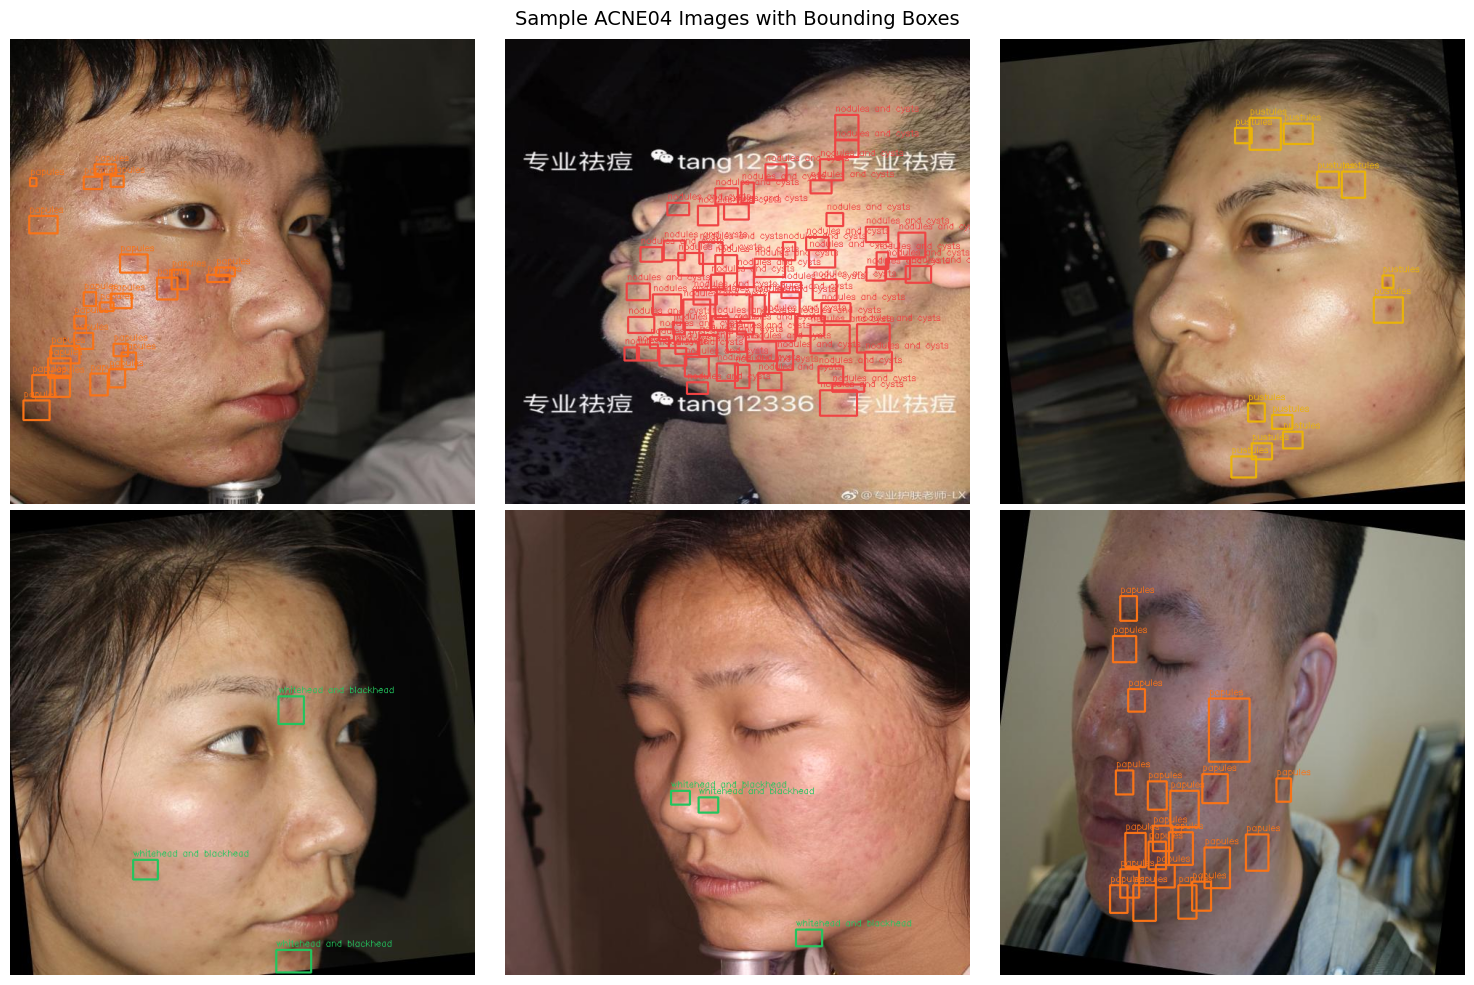

In [10]:
def draw_boxes(image_path, label_path, class_names):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    colors = [(239,68,68), (249,115,22), (234,179,8), (34,197,94)]
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            class_id = int(parts[0])
            x_center, y_center, bw, bh = map(float, parts[1:])
            x1 = int((x_center - bw/2) * w)
            y1 = int((y_center - bh/2) * h)
            x2 = int((x_center + bw/2) * w)
            y2 = int((y_center + bh/2) * h)
            color = colors[class_id]
            cv2.rectangle(image, (x1,y1), (x2,y2), color, 2)
            cv2.putText(image, class_names[class_id], (x1, y1-5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    return image

image_files = list((ACNE04 / 'train' / 'images').glob('*.jpg'))
samples = random.sample(image_files, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flat, samples):
    label_path = ACNE04 / 'train' / 'labels' / img_path.with_suffix('.txt').name
    img = draw_boxes(img_path, label_path, CLASS_NAMES)
    ax.imshow(img)
    ax.axis('off')

plt.suptitle('Sample ACNE04 Images with Bounding Boxes', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/predictions/eda_sample_images.png', dpi=150)
plt.show()

### Observations
- Significant visual variation across images: lighting, camera quality, skin tone, and angle differ substantially
- Some images contain Chinese watermarks which may introduce noise during training
- Dense annotation cases show heavily overlapping bounding boxes — these are the hardest cases for any detector
- The dataset is predominantly East Asian subjects, which is noted as a potential limitation for cross-demographic generalization

## 5. Patch Quality Check

Patch distribution:
  train/acne:  39713
  train/clear: 8919
  val/acne:    3423
  val/clear:   849
  train ratio (acne:clear): 4.45:1


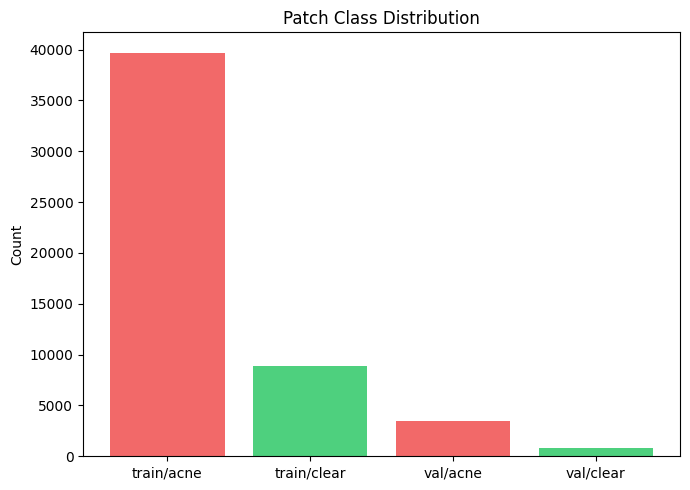

In [12]:
patch_dir = Path('data/patches')

train_acne = len(list((patch_dir / 'train' / 'acne').glob('*.jpg')))
train_clear = len(list((patch_dir / 'train' / 'clear').glob('*.jpg')))
val_acne = len(list((patch_dir / 'val' / 'acne').glob('*.jpg')))
val_clear = len(list((patch_dir / 'val' / 'clear').glob('*.jpg')))

print('Patch distribution:')
print(f'  train/acne:  {train_acne}')
print(f'  train/clear: {train_clear}')
print(f'  val/acne:    {val_acne}')
print(f'  val/clear:   {val_clear}')
print(f'  train ratio (acne:clear): {train_acne/train_clear:.2f}:1')

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['train/acne', 'train/clear', 'val/acne', 'val/clear'],
       [train_acne, train_clear, val_acne, val_clear],
       color=['#ef4444', '#22c55e', '#ef4444', '#22c55e'], alpha=0.8)
ax.set_title('Patch Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/predictions/eda_patch_distribution.png', dpi=150)
plt.show()

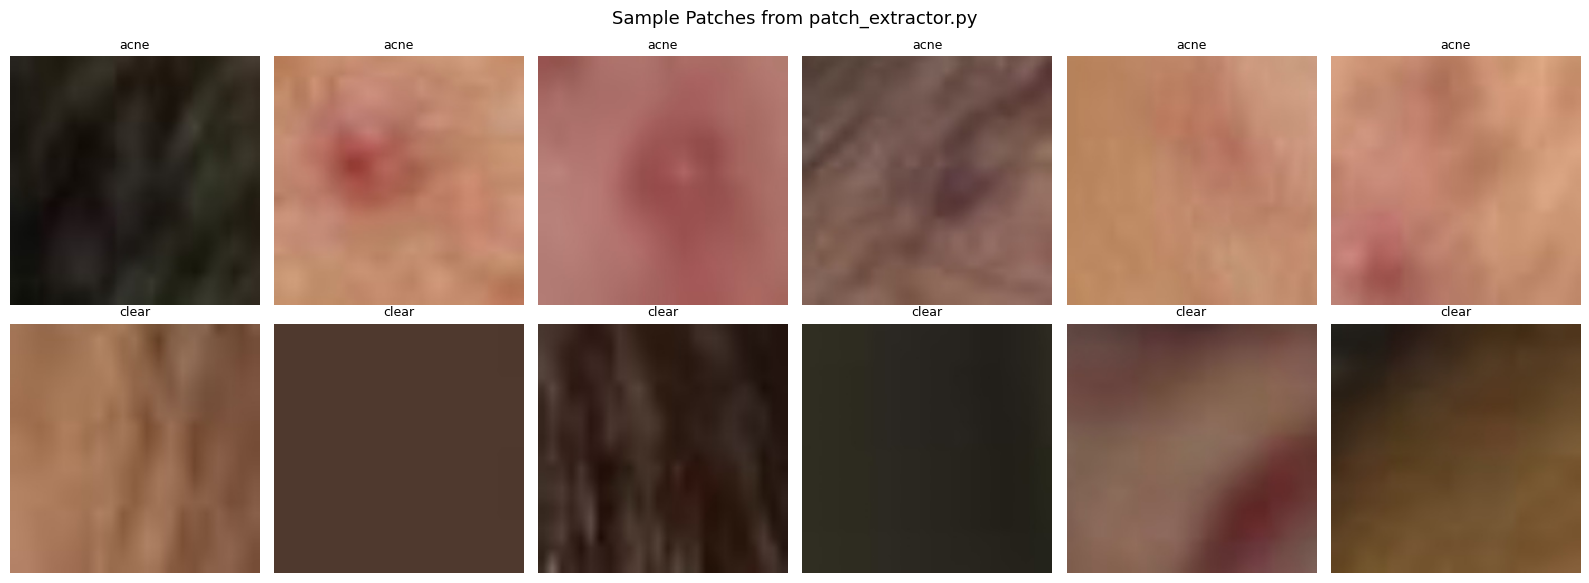

In [13]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))

acne_patches = random.sample(list((patch_dir / 'train' / 'acne').glob('*.jpg')), 6)
for ax, patch_path in zip(axes[0], acne_patches):
    img = cv2.imread(str(patch_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title('acne', fontsize=9)
    ax.axis('off')

clear_patches = random.sample(list((patch_dir / 'train' / 'clear').glob('*.jpg')), 6)
for ax, patch_path in zip(axes[1], clear_patches):
    img = cv2.imread(str(patch_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title('clear', fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Patches from patch_extractor.py', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/predictions/eda_sample_patches.png', dpi=150)
plt.show()

### Observations
- Acne patches show clear visual diversity across lesion types — consistent with the 4-class annotation scheme
- Clear patches represent close-up skin texture at the same scale as acne patches after fixing negative crop size to match average bounding box dimensions
- A small number of dark/black patches were observed — these arise from background regions at image edges and are filtered by the brightness threshold in patch_extractor.py
- Final patch distribution: 39,713 train acne / 8,919 train clear (~4.45:1 ratio) — class imbalance addressed via weighted loss during Part 2 classifier training